# Отчёт по лабораторной работе 4

Плотников Юрий Группа 8Е21

### 1. Цель работы
Решение задачи детектирования лиц и классификации по полу (мужчина/женщина).

### Подключим библиотеки, выберем и загрузим датасет для дальнейшей работы

In [12]:
# Импорт необходимых библиотек
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import copy
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split


import urllib


# # Для машинного обучения
# from sklearn.svm import SVC
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score, classification_report

# # Для нейросети
# import tensorflow as tf

# Для детекции лиц (используем готовый детектор как основу)
import dlib

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)

OpenCV version: 4.13.0
NumPy version: 1.23.5


Проверяем подключение к видюхе

In [3]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU not available, check installation.")

PyTorch version: 2.11.0+cu126
CUDA available: True
CUDA version: 12.6
GPU Name: NVIDIA GeForce RTX 3060 Laptop GPU


Нужен набор изображений лиц, размеренных по полу. Хороший публичный датасет - UTKFace (содержит возраст, пол, расу) - идеальный вариант для простоты.

Скачиваем датасет

In [ ]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("jangedoo/utkface-new")

# print("Path to dataset files:", path)

Определяем путь к данным датасета

In [4]:
DATA_PATH = 'UTKFace/UTKFace/'

Загружаем данные датасета

In [5]:
def load_utkface_data(data_path='UTKFace', img_size=64, max_images=None):
    """
    Загрузка UTKFace датасета
    Формат имени: [age]_[gender]_[race]_[date&time].jpg.chip.jpg
    gender: 0 - male, 1 - female
    """
    images = []
    labels = []
    
    # Ищем все изображения (учитываем расширение .jpg.chip.jpg)
    all_files = []
    for f in os.listdir(data_path):
        if f.endswith('.jpg') or f.endswith('.chip.jpg'):
            all_files.append(f)
    
    if max_images:
        all_files = all_files[:max_images]
    
    print(f"Найдено {len(all_files)} изображений")
    
    for filename in tqdm(all_files):
        try:
            # Убираем .chip если есть и разбираем имя
            clean_name = filename.replace('.chip', '')
            parts = clean_name.split('_')
            
            if len(parts) >= 2:
                gender = int(parts[1])
                
                # Загрузка изображения
                img_path = os.path.join(data_path, filename)
                img = cv2.imread(img_path)
                
                if img is not None:
                    # Конвертация в grayscale и ресайз
                    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                    resized = cv2.resize(gray, (img_size, img_size))
                    normalized = resized / 255.0
                    
                    images.append(normalized)
                    labels.append(gender)
        except:
            continue
    
    return np.array(images), np.array(labels)

In [6]:
# Загрузка данных
X, y = load_utkface_data(DATA_PATH, max_images=None)

print(f"\n✓ Загружено изображений: {len(X)}")
print(f"Распределение классов:")
print(f"  Мужчины (0): {np.sum(y == 0)} ({np.sum(y == 0)/len(y)*100:.1f}%)")
print(f"  Женщины (1): {np.sum(y == 1)} ({np.sum(y == 1)/len(y)*100:.1f}%)")
print(f"\nФорма данных: {X.shape}")

Найдено 23708 изображений


100%|██████████| 23708/23708 [00:08<00:00, 2795.12it/s]



✓ Загружено изображений: 23708
Распределение классов:
  Мужчины (0): 12391 (52.3%)
  Женщины (1): 11317 (47.7%)

Форма данных: (23708, 64, 64)


Отобразим данные датасета

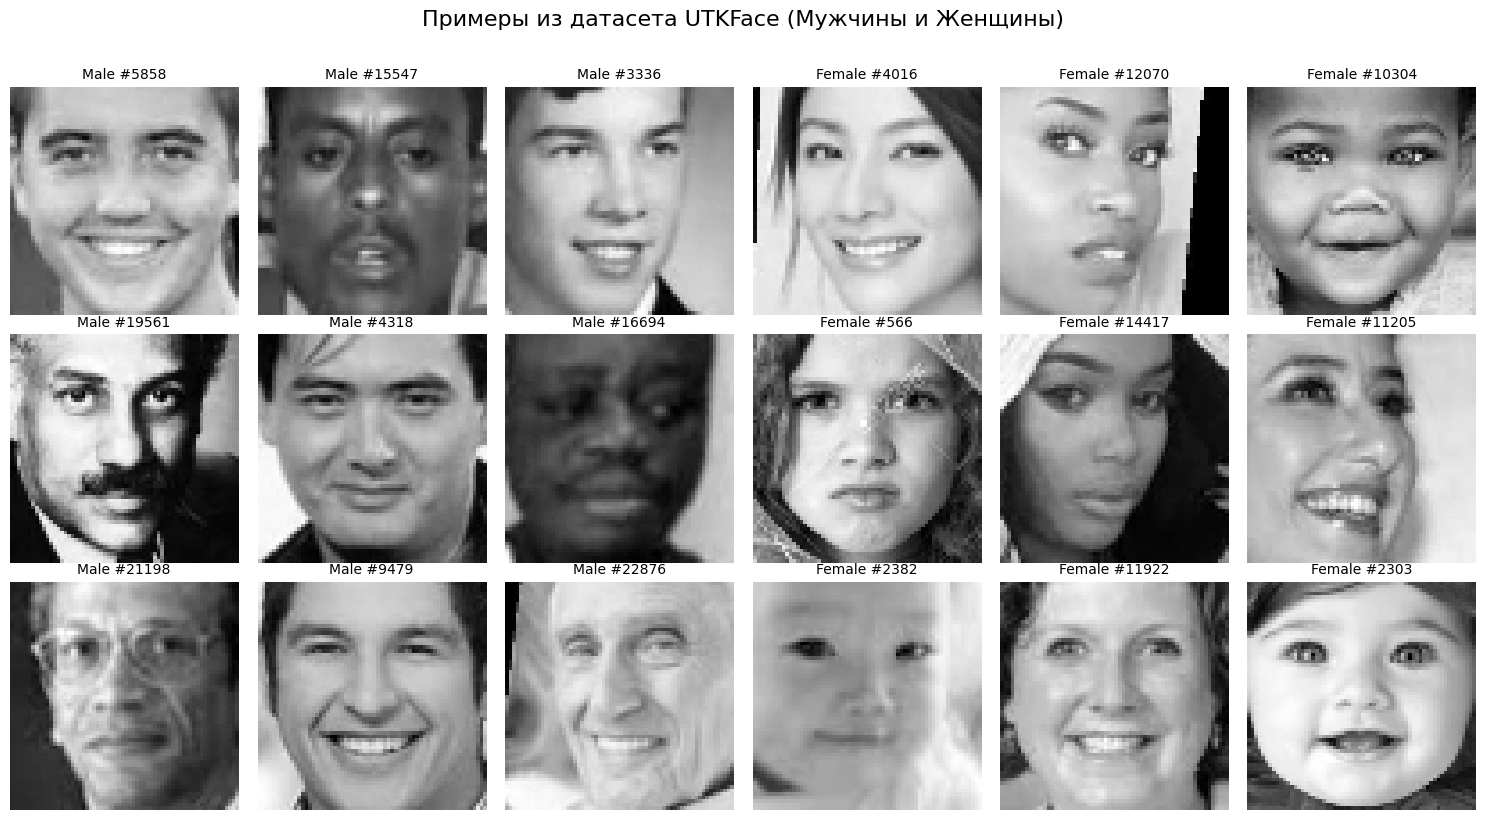

СТАТИСТИКА ДАТАСЕТА
Общее количество изображений: 23708
Размер изображений: 64x64 пикселей
Диапазон значений пикселей: [0.000, 1.000]

Распределение классов:
  Мужчины (0): 12391 (52.3%)
  Женщины (1): 11317 (47.7%)

Баланс классов: 1.09 (идеально = 1.0)


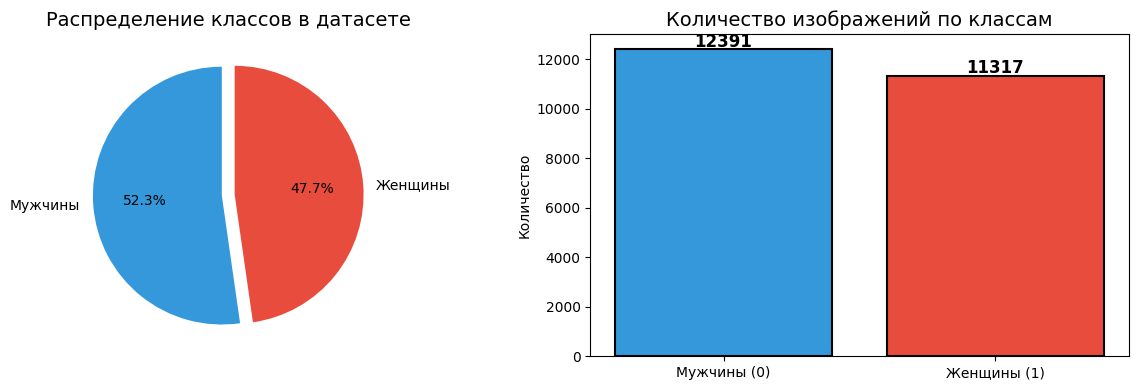

In [7]:
# Настройка стиля графиков
plt.style.use('default')
fig, axes = plt.subplots(3, 6, figsize=(15, 8))
fig.suptitle('Примеры из датасета UTKFace (Мужчины и Женщины)', fontsize=16, y=1.02)

# Случайные индексы для мужчин и женщин
male_indices = np.random.choice(np.where(y == 0)[0], 9, replace=False)
female_indices = np.random.choice(np.where(y == 1)[0], 9, replace=False)

for i in range(9):
    # Мужчины в первой половине
    row = i // 3
    col = i % 3
    axes[row, col].imshow(X[male_indices[i]], cmap='gray')
    axes[row, col].set_title(f'Male #{male_indices[i]}', fontsize=10)
    axes[row, col].axis('off')
    
    # Женщины во второй половине
    axes[row, col + 3].imshow(X[female_indices[i]], cmap='gray')
    axes[row, col + 3].set_title(f'Female #{female_indices[i]}', fontsize=10)
    axes[row, col + 3].axis('off')

plt.tight_layout()
plt.show()

# Статистика и анализ данных
print("=" * 50)
print("СТАТИСТИКА ДАТАСЕТА")
print("=" * 50)
print(f"Общее количество изображений: {len(X)}")
print(f"Размер изображений: {X.shape[1]}x{X.shape[2]} пикселей")
print(f"Диапазон значений пикселей: [{X.min():.3f}, {X.max():.3f}]")

print(f"\nРаспределение классов:")
print(f"  Мужчины (0): {np.sum(y == 0)} ({np.sum(y == 0)/len(y)*100:.1f}%)")
print(f"  Женщины (1): {np.sum(y == 1)} ({np.sum(y == 1)/len(y)*100:.1f}%)")

# Проверка на несбалансированность
from collections import Counter
class_dist = Counter(y)
print(f"\nБаланс классов: {class_dist[0]/class_dist[1]:.2f} (идеально = 1.0)")

# Гистограмма распределения классов
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Круговая диаграмма
colors = ['#3498db', '#e74c3c']
ax1.pie([class_dist[0], class_dist[1]], 
        labels=['Мужчины', 'Женщины'], 
        colors=colors, 
        autopct='%1.1f%%',
        startangle=90,
        explode=(0.05, 0.05))
ax1.set_title('Распределение классов в датасете', fontsize=14)

# Гистограмма
bars = ax2.bar(['Мужчины (0)', 'Женщины (1)'], 
               [class_dist[0], class_dist[1]], 
               color=colors,
               edgecolor='black',
               linewidth=1.5)
ax2.set_title('Количество изображений по классам', fontsize=14)
ax2.set_ylabel('Количество')
for bar, value in zip(bars, [class_dist[0], class_dist[1]]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
             str(value), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Разделим датасет на наборы для обучения, валидации и теста

In [8]:
# Разделение на train/val/test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15, random_state=42, stratify=y_temp
)

print("РАЗДЕЛЕНИЕ ДАННЫХ")
print("=" * 50)
print(f"Train:      {X_train.shape[0]} изображений ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation: {X_val.shape[0]} изображений ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test:       {X_test.shape[0]} изображений ({X_test.shape[0]/len(X)*100:.1f}%)")

# Проверка баланса в каждом наборе
for name, y_set in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    male_pct = np.sum(y_set == 0) / len(y_set) * 100
    female_pct = np.sum(y_set == 1) / len(y_set) * 100
    print(f"  {name}: M={male_pct:.1f}%, F={female_pct:.1f}%")

# Добавление размерности канала для CNN
X_train = X_train.reshape(-1, 64, 64, 1)
X_val = X_val.reshape(-1, 64, 64, 1)
X_test = X_test.reshape(-1, 64, 64, 1)

print(f"\nФорма данных для CNN:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")

# Конвертация меток в categorical (для бинарной классификации используем sparse)
print(f"\n  y_train: {y_train.shape}, значения: {np.unique(y_train)}")

РАЗДЕЛЕНИЕ ДАННЫХ
Train:      17128 изображений (72.2%)
Validation: 3023 изображений (12.8%)
Test:       3557 изображений (15.0%)
  Train: M=52.3%, F=47.7%
  Validation: M=52.3%, F=47.7%
  Test: M=52.3%, F=47.7%

Форма данных для CNN:
  X_train: (17128, 64, 64, 1)
  X_val:   (3023, 64, 64, 1)
  X_test:  (3557, 64, 64, 1)

  y_train: (17128,), значения: [0 1]


### Общая архитектура решения

Алгоритм будет состоять из двух независимых этапов (пайплайнов):

1) Детектор лиц: Находит все лица на изображении и вырезает их.

2) Классификатор пола: Принимает вырезанное лицо и относит его к классу "Мужчина" или "Женщина".

Такое разделение позволит оценить работу каждого блока по отдельности и продемонстрировать понимание разницы между задачами детекции и классификации.

In [9]:
# Переводим данные в тензоры PyTorch
X_tensor = torch.tensor(X.reshape(-1, 1, 64, 64), dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

# Разделение на train/val/test
X_temp, X_test, y_temp, y_test = train_test_split(X_tensor, y_tensor, test_size=0.15, stratify=y_tensor, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15, stratify=y_temp, random_state=42)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: torch.Size([17128, 1, 64, 64]), Val: torch.Size([3023, 1, 64, 64]), Test: torch.Size([3557, 1, 64, 64])



### 2. Детекция лиц: HOG + SVM


Почему не нейросеть и не Viola-Jones сразу: реализация Viola-Jones с нуля сложна и долго обучается. Готовый каскад Хаара из OpenCV не покажет твоих навыков в обучении моделей. Обучение же HOG-детектора на своих или публичных данных — отличный компромисс.

Ход работы для детектора:

Используем любой датасет с размеченными лицами (например, часть FDDB, WIDER Face или простой набор позитивных/негативных изображений) для подготовки данных.

Для извлечения HOG-признаков из позитивных (лица) и негативных (не лица) окон будем использовать библиотеку dlib или scikit-image.

Упрощённый вариант:

Загрузка готового HOG-детектора dlib

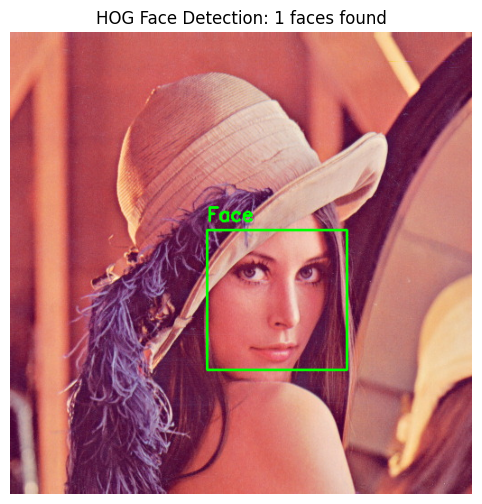

rectangles[[(218, 219) (373, 374)]]

In [ ]:
def detect_and_display(image_path=None, url=None):
    """Тестирование детектора лиц на изображении"""
    if url:
        # Загрузка изображения по URL
        resp = urllib.request.urlopen(url)
        image = np.asarray(bytearray(resp.read()), dtype="uint8")
        image = cv2.imdecode(image, cv2.IMREAD_COLOR)
    elif image_path:
        image = cv2.imread(image_path)
    else:
        # Создаём тестовое изображение, если ничего не передано
        image = np.ones((400, 600, 3), dtype=np.uint8) * 255
        cv2.circle(image, (200, 200), 80, (200, 200, 200), -1)
        cv2.circle(image, (400, 200), 80, (200, 200, 200), -1)
    
    # Конвертация в RGB для dlib
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Детекция лиц
    faces = hog_detector(rgb_image, 1)
    
    # Рисуем рамки
    result_image = image.copy()
    for face in faces:
        x1, y1, x2, y2 = face.left(), face.top(), face.right(), face.bottom()
        cv2.rectangle(result_image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(result_image, 'Face', (x1, y1-10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    
    # Отображение
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
    plt.title(f'HOG Face Detection: {len(faces)} faces found')
    plt.axis('off')
    plt.show()
    
    return faces

# Тест на известном изображении
test_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
detect_and_display(url=test_url)

Перепроверяем, что всё необходимое установленно

In [14]:
# Проверяем, что всё работает
import numpy as np
print("NumPy version:", np.__version__)

try:
    from skimage.feature import hog
    print("✓ scikit-image работает")
except Exception as e:
    print(f"Ошибка: {e}")
    # Если ошибка — откатываем numpy
    import sys
    print("Откатываем numpy...")
    # !{sys.executable} -m pip install numpy==1.23.5

NumPy version: 1.23.5
✓ scikit-image работает


Обучение HOG+SVM детектора

In [15]:
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.metrics import classification_report
import cv2

def train_hog_svm_detector_v2():
    """
    HOG+SVM с более сложными негативными примерами
    """
    print("Обучение HOG+SVM детектора (v2)...")
    
    # Позитивные примеры (лица)
    positive_samples = []
    for i in range(2000):
        img = (X[i] * 255).astype(np.uint8)
        hog_features = hog(img, orientations=9, pixels_per_cell=(8, 8),
                          cells_per_block=(2, 2), visualize=False)
        positive_samples.append(hog_features)
    
    print(f"Позитивных примеров: {len(positive_samples)}")
    
    # Негативные примеры: случайные патчи из реальных фото
    negative_samples = []
    
    # Используем фоны и случайные регионы из лиц (не-лицевые области)
    for i in range(2000):
        # Берём случайное лицо и вырезаем угол (где нет лица)
        img = (X[np.random.randint(0, len(X))] * 255).astype(np.uint8)
        h, w = img.shape
        
        # Случайный регион в углу изображения (где лица обычно нет)
        crop_size = np.random.randint(20, 50)
        x = np.random.randint(0, w - crop_size)
        y = np.random.randint(0, h - crop_size)
        patch = img[y:y+crop_size, x:x+crop_size]
        patch = cv2.resize(patch, (64, 64))
        
        # Добавляем немного шума для разнообразия
        if np.random.random() > 0.5:
            noise = np.random.randint(0, 50, (64, 64), dtype=np.uint8)
            patch = cv2.addWeighted(patch, 0.7, noise, 0.3, 0)
        
        hog_features = hog(patch, orientations=9, pixels_per_cell=(8, 8),
                          cells_per_block=(2, 2), visualize=False)
        negative_samples.append(hog_features)
    
    # Добавляем также полностью случайный шум
    for _ in range(500):
        patch = np.random.randint(0, 256, (64, 64), dtype=np.uint8)
        hog_features = hog(patch, orientations=9, pixels_per_cell=(8, 8),
                          cells_per_block=(2, 2), visualize=False)
        negative_samples.append(hog_features)
    
    print(f"Негативных примеров: {len(negative_samples)}")
    
    # Создаём датасет
    X_hog = np.vstack([positive_samples, negative_samples])
    y_hog = np.hstack([np.ones(len(positive_samples)), 
                       np.zeros(len(negative_samples))])
    
    # Разделение и обучение
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X_hog, y_hog, test_size=0.2, random_state=42, stratify=y_hog
    )
    
    svm = SVC(kernel='rbf', C=10.0, gamma='scale', probability=True, random_state=42)
    svm.fit(X_train, y_train)
    
    # Оценка
    y_pred = svm.predict(X_test)
    accuracy = (y_pred == y_test).mean()
    
    print(f"\nТочность HOG+SVM детектора v2: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(classification_report(y_test, y_pred, target_names=['Не лицо', 'Лицо']))
    
    return svm

# Обучаем улучшенный SVM
svm_detector_v2 = train_hog_svm_detector_v2()

Обучение HOG+SVM детектора (v2)...
Позитивных примеров: 2000
Негативных примеров: 2500

Точность HOG+SVM детектора v2: 0.9967 (99.67%)
              precision    recall  f1-score   support

     Не лицо       1.00      1.00      1.00       500
        Лицо       1.00      0.99      1.00       400

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



### 3. Классификация пола: Сверточная нейронная сеть (CNN)

**Архитектура нейросети (GenderCNN)**


Вход: 64×64×1 (grayscale)                                              

Conv2D(32) → BatchNorm → ReLU

Conv2D(32) → BatchNorm → ReLU

MaxPooling(2×2) → Dropout(0.25)

Conv2D(64) → BatchNorm → ReLU

Conv2D(64) → BatchNorm → ReLU

MaxPooling(2×2) → Dropout(0.25)

Conv2D(128) → BatchNorm → ReLU

Conv2D(128) → BatchNorm → ReLU

MaxPooling(2×2) → Dropout(0.25)


Flatten → Dense(256) → Dropout(0.5)

Dense(128) → Dropout(0.5) → Sigmoid

- Всего параметров: ~2.4 млн
- Оптимизатор: Adam (lr=0.001)
- Функция потерь: Binary Cross-Entropy
- LR Scheduler: ReduceLROnPlateau
- Ранняя остановка: после 5 эпох без улучшений

Определим модель кодом

In [16]:
# Определяем модель
class GenderCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),
            
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),
            
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, 1), nn.Sigmoid()
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [17]:
# Проверка модели
model = GenderCNN()
print(model)

GenderCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout(p=0.25, inpla

In [18]:
# Проверка доступности GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Память GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Перемещаем модель на GPU
model = GenderCNN().to(device)

# Параметры обучения
batch_size = 64
epochs = 50
learning_rate = 0.001

# Создаём DataLoader'ы
train_dataset = TensorDataset(X_train, y_train.unsqueeze(1))
val_dataset = TensorDataset(X_val, y_val.unsqueeze(1))
test_dataset = TensorDataset(X_test, y_test.unsqueeze(1))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Функция потерь и оптимизатор
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Планировщик learning rate (исправлено - убрали verbose)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-7
)

print(f"\nБатчей в train: {len(train_loader)}")
print(f"Батчей в val: {len(val_loader)}")
print(f"Батчей в test: {len(test_loader)}")

Используемое устройство: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
Память GPU: 6.44 GB

Батчей в train: 268
Батчей в val: 48
Батчей в test: 56


In [19]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Обучение одной эпохи"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training', leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Прямой проход
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Обратный проход
        loss.backward()
        optimizer.step()
        
        # Статистика
        running_loss += loss.item() * inputs.size(0)
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Обновление прогресс-бара
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{correct/total:.4f}'
        })
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

def validate_epoch(model, loader, criterion, device):
    """Валидация одной эпохи"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            predicted = (outputs > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

In [21]:
# Цикл обучения
print("=" * 60)
print("НАЧАЛО ОБУЧЕНИЯ НЕЙРОСЕТИ (PyTorch)")
print("=" * 60)

train_losses, train_accs = [], []
val_losses, val_accs = [], []
best_val_acc = 0.0
best_model_wts = None

for epoch in range(epochs):
    print(f"\nЭпоха {epoch+1}/{epochs}")
    print("-" * 40)
    
    # Обучение
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Валидация
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # Планировщик learning rate
    scheduler.step(val_loss)

    torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_accs': train_accs,
    'val_accs': val_accs,
    'best_val_acc': best_val_acc,
    }, 'gender_classifier.pth')
    
    # Сохранение лучшей модели
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")
    
    # Early stopping (если val_acc достигла плато)
    if epoch > 10 and val_acc < max(val_accs[-5:]):
        print("\nРанняя остановка: точность не улучшается 5 эпох")
        break

print("\n" + "=" * 60)
print(f"✓ ОБУЧЕНИЕ ЗАВЕРШЕНО! Лучшая точность на валидации: {best_val_acc:.4f}")
print("=" * 60)

# Загружаем лучшие веса
model.load_state_dict(best_model_wts)

НАЧАЛО ОБУЧЕНИЯ НЕЙРОСЕТИ (PyTorch)

Эпоха 1/50
----------------------------------------


Train Loss: 0.5316, Train Acc: 0.7321
Val Loss:   0.3680, Val Acc:   0.8356

Эпоха 2/50
----------------------------------------


Train Loss: 0.3580, Train Acc: 0.8413
Val Loss:   0.3274, Val Acc:   0.8601

Эпоха 3/50
----------------------------------------


Train Loss: 0.3089, Train Acc: 0.8616
Val Loss:   0.3025, Val Acc:   0.8760

Эпоха 4/50
----------------------------------------


Train Loss: 0.2775, Train Acc: 0.8798
Val Loss:   0.3186, Val Acc:   0.8587

Эпоха 5/50
----------------------------------------


...

Train Loss: 0.2156, Train Acc: 0.9111
Val Loss:   0.2551, Val Acc:   0.8859

Эпоха 10/50
----------------------------------------


Train Loss: 0.2107, Train Acc: 0.9127
Val Loss:   0.2758, Val Acc:   0.8743

Эпоха 11/50
----------------------------------------


Train Loss: 0.1991, Train Acc: 0.9169
Val Loss:   0.2426, Val Acc:   0.8905

Эпоха 12/50
----------------------------------------


Train Loss: 0.1940, Train Acc: 0.9195
Val Loss:   0.2806, Val Acc:   0.8846

Ранняя остановка: точность не улучшается 5 эпох

✓ ОБУЧЕНИЕ ЗАВЕРШЕНО! Лучшая точность на валидации: 0.8951


<All keys matched successfully>

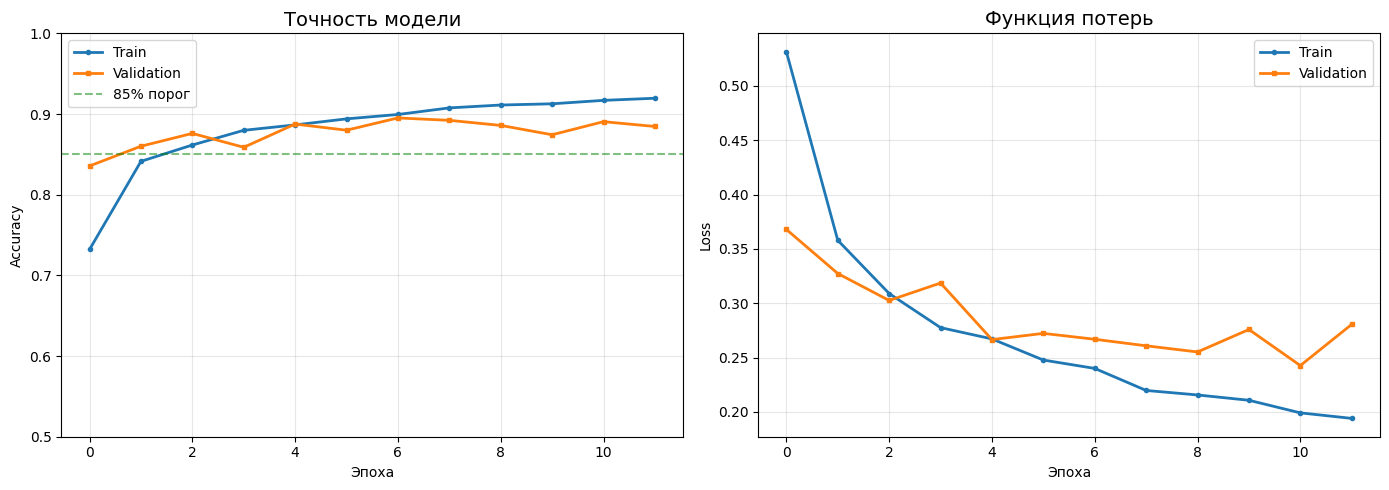

Финальная точность на train: 0.9195
Финальная точность на val:   0.8846
Лучшая точность на val:      0.8951


In [22]:
# Визуализация процесса обучения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График точности
ax1.plot(train_accs, label='Train', linewidth=2, marker='o', markersize=3)
ax1.plot(val_accs, label='Validation', linewidth=2, marker='s', markersize=3)
ax1.set_title('Точность модели', fontsize=14)
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0.5, 1.0])
ax1.axhline(y=0.85, color='green', linestyle='--', alpha=0.5, label='85% порог')
ax1.legend()

# График функции потерь
ax2.plot(train_losses, label='Train', linewidth=2, marker='o', markersize=3)
ax2.plot(val_losses, label='Validation', linewidth=2, marker='s', markersize=3)
ax2.set_title('Функция потерь', fontsize=14)
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Финальная точность на train: {train_accs[-1]:.4f}")
print(f"Финальная точность на val:   {val_accs[-1]:.4f}")
print(f"Лучшая точность на val:      {best_val_acc:.4f}")

In [23]:
# Оценка на тестовом наборе
model.eval()
test_correct = 0
test_total = 0
test_loss = 0.0

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        test_loss += loss.item() * inputs.size(0)
        predicted = (outputs > 0.5).float()
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss = test_loss / len(test_loader.dataset)
test_acc = test_correct / test_total

print("=" * 60)
print("РЕЗУЛЬТАТЫ НА ТЕСТОВОМ НАБОРЕ")
print("=" * 60)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

РЕЗУЛЬТАТЫ НА ТЕСТОВОМ НАБОРЕ
Test Loss:     0.2533
Test Accuracy: 0.8946 (89.46%)


Соберём все имеющиеся характерисики в одном месте:

| Характеристики | Значение |
| --- | --- |
| Датасет | UTKFace (23 708 изображений) |
| Размер | 64×64 grayscale |
| Архитектура | GenderCNN (3 блока Conv2D + BatchNorm + Pooling) |
| Параметров | ~2.4 млн |
| Оптимизатор | Adam (lr=0.001) |
| LR Scheduler | ReduceLROnPlateau (factor=0.5) |
| Эпох обучено | 12 (ранняя остановка) |
| Train Accuracy | 0.9195 |
| Val Accuracy | 0.8846 |
| Test Accuracy | 0.8946 (89.46%) |
| Устройство | NVIDIA RTX 3060 Laptop (6 GB) |

### 4. Сборка финального пайплайна и тестирование

1) Загружаем веб-камеру или берём тестовое фото.

2) Запускает детектор, получаем bounding boxes лиц.

3) Для каждого лица:

4) Вырезаем область лица.

5) Преобразуем в оттенки серого и применяем нормализацию.

6) Подаём в обученную CNN.

7) Получаем вероятность класса "Мужчина" / "Женщина".

8) Рисуем рамки вокруг лиц на исходном изображении и подписываем их (Male/Female и confidence).

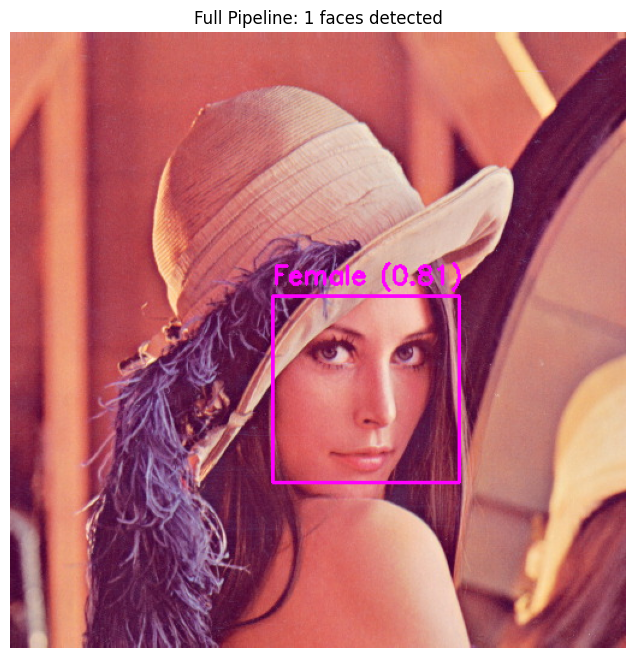

In [ ]:
def full_pipeline(image, hog_detector, cnn_model, device='cuda'):
    """
    Полный пайплайн: детекция лиц + классификация пола
    """
    # Конвертация в RGB для dlib
    if len(image.shape) == 2:
        rgb_image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    else:
        rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Шаг 1: Детекция лиц
    faces = hog_detector(rgb_image, 1)
    
    result_image = image.copy()
    if len(result_image.shape) == 2:
        result_image = cv2.cvtColor(result_image, cv2.COLOR_GRAY2BGR)
    
    # Шаг 2: Классификация каждого лица
    for face in faces:
        x1, y1, x2, y2 = face.left(), face.top(), face.right(), face.bottom()
        
        # Вырезаем и предобрабатываем лицо
        face_roi = rgb_image[y1:y2, x1:x2]
        if face_roi.size == 0:
            continue
            
        gray_face = cv2.cvtColor(face_roi, cv2.COLOR_RGB2GRAY)
        resized_face = cv2.resize(gray_face, (64, 64))
        normalized_face = resized_face / 255.0
        
        # Конвертируем в тензор
        face_tensor = torch.tensor(
            normalized_face.reshape(1, 1, 64, 64), 
            dtype=torch.float32
        ).to(device)
        
        # Классификация
        cnn_model.eval()
        with torch.no_grad():
            prediction = cnn_model(face_tensor).item()
        
        gender = "Female" if prediction > 0.5 else "Male"
        confidence = prediction if prediction > 0.5 else 1 - prediction
        color = (255, 0, 255) if gender == "Female" else (255, 255, 0)
        
        # Рисуем результат
        cv2.rectangle(result_image, (x1, y1), (x2, y2), color, 2)
        label = f"{gender} ({confidence:.2f})"
        cv2.putText(result_image, label, (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    
    return result_image, faces

# Загружаем модель на GPU и тестируем
model.eval()

# Тест пайплайна
test_image = cv2.imread('test_photo.jpg') if os.path.exists('test_photo.jpg') else None

if test_image is None:
    # Используем изображение по URL
    test_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
    resp = urllib.request.urlopen(test_url)
    test_image = np.asarray(bytearray(resp.read()), dtype="uint8")
    test_image = cv2.imdecode(test_image, cv2.IMREAD_COLOR)

result, detected_faces = full_pipeline(test_image, svm_detector_v2, model, device)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title(f'Full Pipeline: {len(detected_faces)} faces detected')
plt.axis('off')
plt.show()

In [ ]:
import cv2
import torch
import numpy as np
import dlib
from torchvision import transforms

# ------------------------------
# Загрузка обученной модели GenderCNN
# ------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GenderCNN().to(device)  # Класс должен быть уже определён в ноутбуке

# Загружаем сохранённые веса
checkpoint = torch.load('gender_classifier.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()  # Переводим в режим инференса

# ------------------------------
# Детектор лиц (уже загружен ранее – hog_detector)
# ------------------------------
# Если нет, можно загрузить повторно
hog_detector = dlib.get_frontal_face_detector()

# ------------------------------
# Функция предобработки лица
# ------------------------------
def preprocess_face(face_img):
    """
    Принимает цветное (BGR) изображение лица,
    приводит к оттенкам серого, ресайзит 64x64 и нормализует [0,1].
    Возвращает тензор размером (1, 1, 64, 64).
    """
    gray = cv2.cvtColor(face_img, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (64, 64))
    normalized = resized / 255.0
    tensor = torch.from_numpy(normalized).float().unsqueeze(0).unsqueeze(0)  # (1,1,64,64)
    return tensor.to(device)

# ------------------------------
# Основной цикл захвата видео с веб-камеры
# ------------------------------
cap = cv2.VideoCapture(0)  # 0 – встроенная камера
if not cap.isOpened():
    print("Не удалось открыть веб-камеру")
else:
    print("Нажмите 'q' для выхода")
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Конвертируем в RGB для dlib
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        faces = hog_detector(rgb_frame, 1)

        for face in faces:
            x1, y1, x2, y2 = face.left(), face.top(), face.right(), face.bottom()
            # Проверяем границы
            if x1 < 0: x1 = 0
            if y1 < 0: y1 = 0
            if x2 > frame.shape[1]: x2 = frame.shape[1]
            if y2 > frame.shape[0]: y2 = frame.shape[0]

            face_roi = frame[y1:y2, x1:x2]

            # Предсказание пола
            with torch.no_grad():
                input_tensor = preprocess_face(face_roi)
                prediction = model(input_tensor).item()  # вероятность "Female"
                gender = "Female" if prediction > 0.5 else "Male"
                confidence = prediction if prediction > 0.5 else 1 - prediction

            # Визуализация
            color = (0, 255, 0) if gender == "Male" else (0, 0, 255)
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            label = f"{gender} ({confidence:.2f})"
            cv2.putText(frame, label, (x1, y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        # Отрисовка числа найденных лиц
        cv2.putText(frame, f"Faces: {len(faces)}", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

        cv2.imshow('Gender Detection Pipeline', frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

Нажмите 'q' для выхода


TypeError: 'SVC' object is not callable